# Plot single-cell doubling times

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import to_hex, to_rgb

# from macrohet import plot

# Define the expanded_piyg color map
expanded_piyg = [
    '#1a9641',  # First color from sns.color_palette('PiYG')
    '#a6d96a',  # Second color from sns.color_palette('PiYG')
    '#978897',  # Rose Quartz in hexadecimal format
    '#d1d1ca',  # Timberwolf in RGB normalized form
    '#f1b6da',  # Second-to-last color from sns.color_palette('PiYG')
    '#d02c91'   # Last color from sns.color_palette('PiYG')
]
# Setup
sns.set(style="white", font="Nimbus Sans")
sns.set_palette(['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91'])
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

### Load single-cell data

In [2]:
pickle_path = '/mnt/OPERA3/Nathan/data/macrohet/macrohet_results/dfs/sc_df.pkl'
df = pd.read_pickle(pickle_path)
df

,Time (hours),Mtb Area (µm),dMtb Area (µm),Mphi Area (µm),dMphi Area (µm),Infection Status,Initial Infection Status,Final Infection Status,x,y,...,dMtb Area between frames (µm),Mtb Area Processed (µm),Time Model (hours),Mtb Area Model (µm),mtb_origin,Doubling Amounts,Doubling Times,r2,Frame,category_rank
0,0.0,0.000000,0.0,4649.351562,2080.574775,NaN,0.0,0.0,107.845200,755.241882,...,NaN,NaN,NaN,NaN,None,None,None,1.0,0,NaN
1,0.5,0.000000,0.0,4973.001953,2080.574775,NaN,0.0,0.0,113.264671,764.392212,...,0.0,NaN,NaN,NaN,None,None,None,1.0,1,NaN
2,1.0,0.000000,0.0,4687.857910,2080.574775,NaN,0.0,0.0,116.562256,767.332825,...,0.0,NaN,NaN,NaN,None,None,None,1.0,2,NaN
3,1.5,0.000000,0.0,4209.064453,2080.574775,NaN,0.0,0.0,111.890106,758.421265,...,0.0,NaN,NaN,NaN,None,None,None,1.0,3,NaN
4,2.0,0.000000,0.0,4061.855225,2080.574775,False,0.0,0.0,114.113556,759.828735,...,0.0,NaN,0.0,0.000000,None,None,None,1.0,4,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604938,74.5,1.318559,0.0,465.719601,-259.532690,1.0,0.0,0.0,199.740707,530.029724,...,NaN,3.754542,70.0,3.831754,NaN,None,None,0.92,149,8.0
604939,75.0,0.000000,0.0,392.506040,-259.532690,0.0,0.0,0.0,200.346191,529.733398,...,NaN,2.771209,70.5,3.993013,NaN,None,None,0.92,150,8.0
604940,75.5,0.000000,0.0,410.295415,-259.532690,0.0,0.0,0.0,200.246902,528.299072,...,NaN,3.285224,71.0,4.152034,NaN,None,None,0.92,151,8.0
604941,76.0,0.000000,0.0,463.708240,-259.532690,0.0,0.0,0.0,200.559875,529.950134,...,NaN,5.251889,71.5,4.311997,NaN,None,None,0.92,152,8.0


# Final

In [6]:
subset_df = df[df['mtb_origin']=='Growth'].copy()
df["Mtb Strain or Drug Compound"] = np.where(df["Compound"].eq("CTRL"), "CTRL", df["Compound"])
width_in = 12
height_in = 6
ctrl_df = df[df["Mtb Strain or Drug Compound"] == "CTRL"]
drug_df = df[df["Mtb Strain or Drug Compound"] != "CTRL"]
bar_height=0.6

/tmp/ipykernel_4034308/2841342843.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


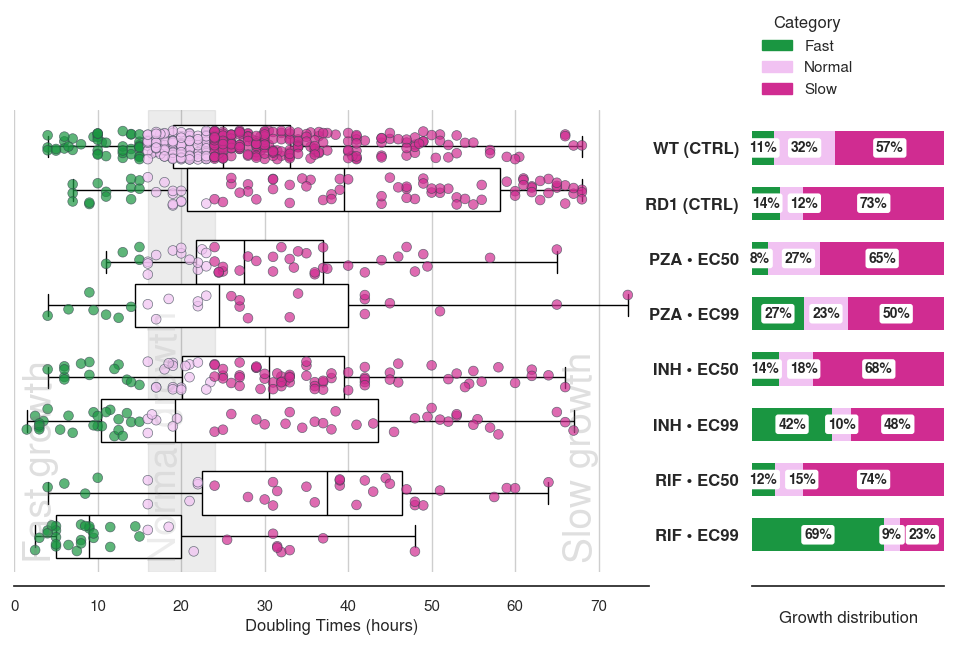

In [79]:
warnings.filterwarnings("ignore", message=".*use_inf_as_na option is deprecated.*")

# --- Data Cleaning & Preparation ---
df = subset_df.copy()

# Normalize columns
for c in ["Compound", "Strain"]:
    if c in df: df[c] = df[c].astype(str)

# Handle Concentration & CTRL logic
mask_ctrl = df["Compound"] == "CTRL"
df["Concentration"] = df.get("Concentration", "EC0").fillna("EC0").astype(str)
df.loc[mask_ctrl, "Concentration"] = "EC0"

# Flatten Doubling Times
df = df.explode("Doubling Times", ignore_index=True)
df["Doubling Times"] = pd.to_numeric(df["Doubling Times"], errors="coerce")
df = df.dropna(subset=["Doubling Times"])
df = df[(df["Doubling Times"] > 0) & (~np.isinf(df["Doubling Times"]))]

# Deduplicate
keys = [k for k in ["ID", "Compound", "Strain", "Concentration", "Doubling Times"] if k in df.columns]
df = df.drop_duplicates(subset=keys).copy()

# Derived labels & Binning
bins = [0, 16, 24, np.inf]
labels = ["Fast", "Normal", "Slow"]
df["Growth Category"] = pd.cut(df["Doubling Times"], bins=bins, labels=labels, right=False)

rd1_aliases = {"ΔRD1", "DeltaRD1", "deltaRD1", "RD1del", "RD1"}
df["Strain_norm"] = np.where(df["Strain"].isin(rd1_aliases), "RD1", "WT")
df["Mtb Strain or Drug Compound"] = np.where(mask_ctrl, "CTRL", df["Compound"])
df["CTRL Type"] = np.where(mask_ctrl, df["Strain_norm"], pd.NA)
df["Display Compound"] = np.where(mask_ctrl, df["Strain_norm"] + " (CTRL)", df["Compound"])

# --- Configuration ---
strain_order = ["CTRL", "PZA", "INH", "RIF"]
right_row_order = ["WT (CTRL)", "RD1 (CTRL)", "PZA", "INH", "RIF"]
conc_order = ["EC50", "EC0", "EC99"]
growth_order = ["Fast", "Normal", "Slow"]

# Colors
fast_c, normal_c, slow_c = expanded_piyg[0], '#F1C2F2', '#D02C91'
growth_colors = {"Fast": fast_c, "Normal": normal_c, "Slow": slow_c}

box_props = {
    'boxprops': {'facecolor': 'white', 'edgecolor': 'black'},
    'medianprops': {'color': 'black'},
    'whiskerprops': {'color': 'black'},
    'capprops': {'color': 'black'}
}

# --- Helper Function for Plotting ---
def plot_overlay(ax, data, hue_col, hue_order):
    """Draws a base boxplot overlayed with growth-category coloured stripplots."""
    if data.empty: return

    # Base Boxplot
    sns.boxplot(
        data=data, x="Doubling Times", y="Mtb Strain or Drug Compound",
        hue=hue_col, order=strain_order, hue_order=hue_order,
        dodge=True, whis=[0, 100], width=0.75, linewidth=1.0, fliersize=0, ax=ax,
        **box_props
    )
    if ax.legend_: ax.legend_.remove()

    # Stripplots (Loop through Growth Categories to apply specific colours)
    present_hues = [h for h in hue_order if h in data[hue_col].unique()]
    
    for cat in growth_order:
        cat_df = data[data["Growth Category"] == cat]
        if cat_df.empty: continue
        
        # Map every hue level to the single color for this growth category
        palette_map = {lvl: growth_colors[cat] for lvl in present_hues}
        
        sns.stripplot(
            data=cat_df, x="Doubling Times", y="Mtb Strain or Drug Compound",
            hue=hue_col, order=strain_order, hue_order=hue_order,
            dodge=True, palette=palette_map,
            jitter=0.25, size=7, linewidth=0.5, edgecolor='#36454F', alpha=0.7, ax=ax
        )
        if ax.legend_: ax.legend_.remove()

# --- Figure Layout ---
fig = plt.figure(figsize=(width_in, height_in))
gs = gridspec.GridSpec(1, 2, width_ratios=[3.3, 1], wspace=0.25)
ax = plt.subplot(gs[0])
ax_bar = plt.subplot(gs[1])

# 1. Left Panel: Control Strips
ctrl_df = df[df["Compound"] == "CTRL"]
if not ctrl_df.empty:
    plot_overlay(ax, ctrl_df, "CTRL Type", list(ctrl_df["CTRL Type"].dropna().unique()))

# 2. Left Panel: Drug Strips
drug_df = df[df["Compound"] != "CTRL"]
for compound in ["PZA", "INH", "RIF"]:
    sub = drug_df[drug_df["Mtb Strain or Drug Compound"] == compound]
    if not sub.empty:
        # Filter hue order to only what's present in this subset
        present_concs = [c for c in conc_order if c in sub["Concentration"].unique()]
        plot_overlay(ax, sub, "Concentration", present_concs)

# Background Bands & Labels
xmax = df["Doubling Times"].max() if not df["Doubling Times"].isna().all() else 75
for txt, b0, b1, alpha in [("Fast", bins[0], bins[1], 0.05), ("Normal", bins[1], bins[2], 0.15), ("Slow", bins[2], xmax+3, 0.05)]:
    shaded_region_colour = 'gray' if txt=='Normal' else 'white'       
    ax.axvspan(b0, b1, alpha=alpha, color=shaded_region_colour)

ymax = len(strain_order) - 0.65
labels_info = [("Fast growth", 1, "left", 0.25), ("Normal growth", 16, "left", 0.15), ("Slow growth", 70, "right", 0.25)]
for txt, xpos, align, alpha in labels_info:
    shaded_region_text_colour = '#36454F' if txt=='Normal' else 'gray'   
    ax.text(xpos, ymax, txt, fontsize=28, color=shaded_region_text_colour, alpha=alpha, ha=align, rotation=90)

ax.set(xlabel="Doubling Times (hours)", ylabel="", yticks=[])
ax.xaxis.grid(True)
sns.despine(offset=10, left=True, ax=ax)

# --- Right Panel: Stacked Bars ---
g = (df.groupby(["Display Compound", "Concentration", "Growth Category"], observed=True)
       .size().unstack("Growth Category", fill_value=0))

# Filter valid rows based on defined order
valid_rows = [(comp, conc) for comp in right_row_order for conc in conc_order 
              if (comp, conc) in g.index and g.loc[(comp, conc)].sum() > 0]

if valid_rows:
    g = g.loc[pd.MultiIndex.from_tuples(valid_rows, names=["Display Compound", "Concentration"])]
    props = g.div(g.sum(axis=1), axis=0).fillna(0.0)

    y_pos = np.arange(len(props))
    lefts = np.zeros(len(props))
    
    # Dictionary to store the X-position of the 'Fast' label for each row
    # Key = row_index, Value = x_center of the Fast label
    fast_label_x = {}
    
    # Minimum distance required between label centers to avoid overlap (0.15 = 15% of width)
    min_separation = 0.2

    for gr in growth_order:
        if gr not in props.columns: continue
        vals = props[gr].values
        
        # Plot bars
        bars = ax_bar.barh(y_pos, vals, left=lefts, height=bar_height, 
                           label=gr, color=growth_colors[gr], edgecolor="none")
        
        # Plot Labels with overlap detection
        for i, (bar, v) in enumerate(zip(bars, vals)):
            if v > 0.05: # Threshold for showing label
                
                # Calculate natural center
                x_center = bar.get_x() + bar.get_width() / 2
                y_center = bar.get_y() + bar.get_height() / 2
                
                # --- LOGIC TO PREVENT OVERLAP ---
                if gr == "Fast":
                    # Store position for the next pass
                    fast_label_x[i] = x_center
                    
                elif gr == "Normal":
                    # Check if we have a Fast label on this row
                    if i in fast_label_x:
                        dist = x_center - fast_label_x[i]
                        # If too close, push Normal label to the right
                        if dist < min_separation:
                            x_center = fast_label_x[i] + min_separation

                # Plot the text at the (potentially adjusted) x_center
                ax_bar.text(x_center, y_center, 
                            f"{v*100:.0f}%", 
                            ha="center", va="center", fontsize=10, fontweight="bold",
                            bbox=dict(facecolor="white", edgecolor="none", boxstyle="round,pad=0.2"))
                            
        lefts += vals

    ax_bar.set(xlim=(0, 1), xticks=[], yticks=y_pos, ylabel="", xlabel="\nGrowth distribution")
    ax_bar.set_yticklabels([f"{c} • {conc}" if conc != 'EC0' else c for c, conc in props.index], fontsize=12, fontweight='bold')
    ax_bar.invert_yaxis()
    sns.despine(offset=10, left=True, ax=ax_bar)

    handles = [mpatches.Patch(color=growth_colors[k], label=k) for k in growth_order]
    ax_bar.legend(handles=handles, title="Category", loc="lower right", frameon=False, bbox_to_anchor=(0.6, 1.0))
else:
    ax_bar.axis("off")
ax.set_xlim(0, 76)
plt.tight_layout()
plt.show()

In [22]:
xmax

np.float64(73.5)